In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
train_sample_path = "train_sample.csv"
test_sample_path = "test_sample.csv"

In [5]:
train_sample = pd.read_csv(train_sample_path)
train_sample.head()

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time
0,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),day,Sunday,NaN,9,1,NaN,high,NaN,1,0.878909,26.907612
1,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Thursday,NaN,7,1,medium,high,NaN,1,1.081668,27.489129
2,Central Jakarta (Jakarta Pusat),East Jakarta (Jakarta Timur),morning,Thursday,NaN,7,0,medium,low,NaN,2,1.192379,27.228978
3,West Jakarta (Jakarta Barat),South Jakarta (Jakarta Selatan),morning,Friday,10.0,9,0,medium,high,fog,1,0.833348,33.943970
4,Central Jakarta (Jakarta Pusat),West Jakarta (Jakarta Barat),day,Tuesday,NaN,7,0,medium,high,rain,2,0.966819,20.603115


In [6]:
test_sample = pd.read_csv(test_sample_path)
X_test = test_sample
X_test.head(3)

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor
0,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),morning,Saturday,5.0,8,1,medium,NaN,NaN,2,1.126429
1,South Jakarta (Jakarta Selatan),East Jakarta (Jakarta Timur),evening,Saturday,NaN,9,1,low,medium,fog,2,1.121015
2,Central Jakarta (Jakarta Pusat),South Jakarta (Jakarta Selatan),morning,Friday,9.0,8,0,high,NaN,rain,1,1.109638


In [7]:
train_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   start_point                    40000 non-null  str    
 1   end_point                      40000 non-null  str    
 2   time_of_day                    40000 non-null  str    
 3   day_of_week                    40000 non-null  str    
 4   traffic_condition              25599 non-null  float64
 5   event_count                    40000 non-null  int64  
 6   is_holiday                     40000 non-null  int64  
 7   vehicle_density                25622 non-null  str    
 8   population_density             25552 non-null  str    
 9   weather                        25571 non-null  str    
 10  public_transport_availability  40000 non-null  int64  
 11  historical_delay_factor        40000 non-null  float64
 12  travel_time                    40000 non-null  float64
dt

In [8]:
train_sample.describe()

,traffic_condition,event_count,is_holiday,public_transport_availability,historical_delay_factor,travel_time
count,25599.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,8.455877,8.704900,0.500975,1.499525,1.009510,30.405411
std,1.829816,5.374108,0.500005,0.671201,0.162034,15.074854
min,3.000000,7.000000,0.000000,0.000000,0.750009,2.490207
25%,9.000000,7.000000,0.000000,1.000000,0.878415,18.685606
50%,9.000000,8.000000,1.000000,2.000000,1.003418,26.604213
75%,10.000000,9.000000,1.000000,2.000000,1.132044,39.771383
max,10.000000,88.000000,1.000000,2.000000,2.701010,218.832465


In [9]:
target_column = "travel_time"

numerical_columns = (
    train_sample.select_dtypes(include=["number"])
      .columns
      .drop(target_column)
)

print(numerical_columns)

Index(['traffic_condition', 'event_count', 'is_holiday',
       'public_transport_availability', 'historical_delay_factor'],
      dtype='str')


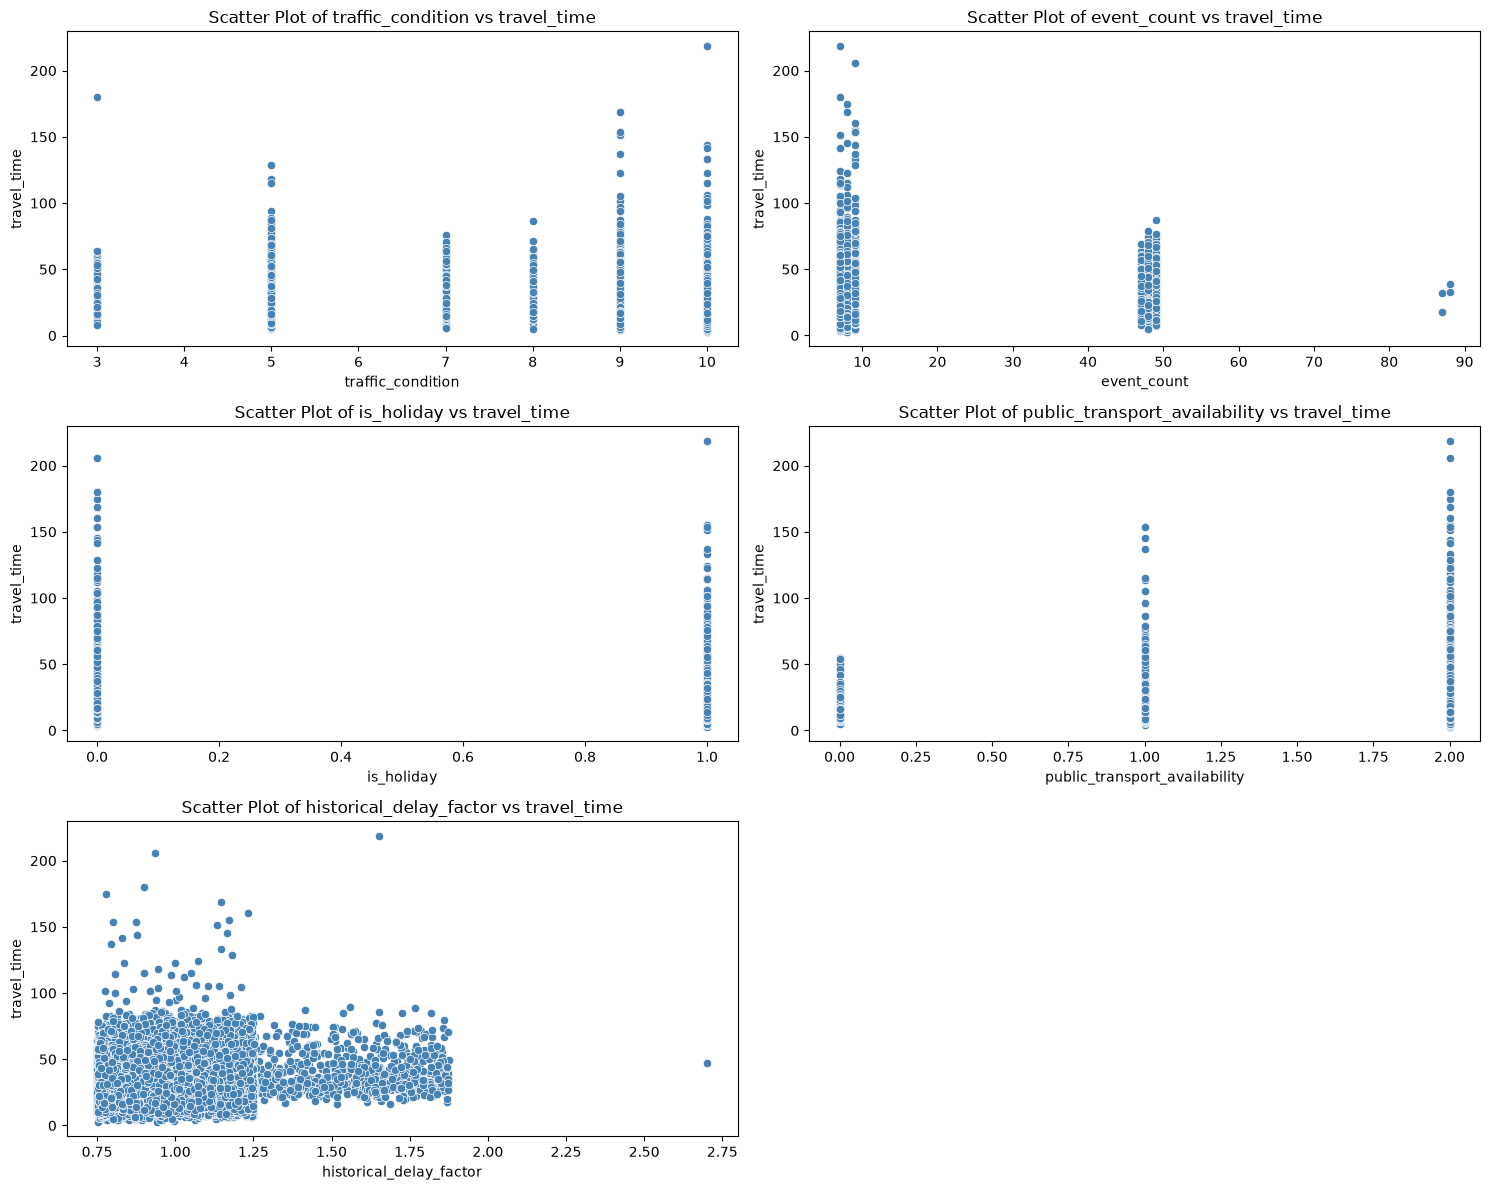

In [10]:
n_cols = 2
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=train_sample[col], y=train_sample['travel_time'], color='steelblue')
    plt.title(f"Scatter Plot of {col} vs travel_time")
    plt.xlabel(col)
    plt.ylabel("travel_time")

plt.tight_layout()

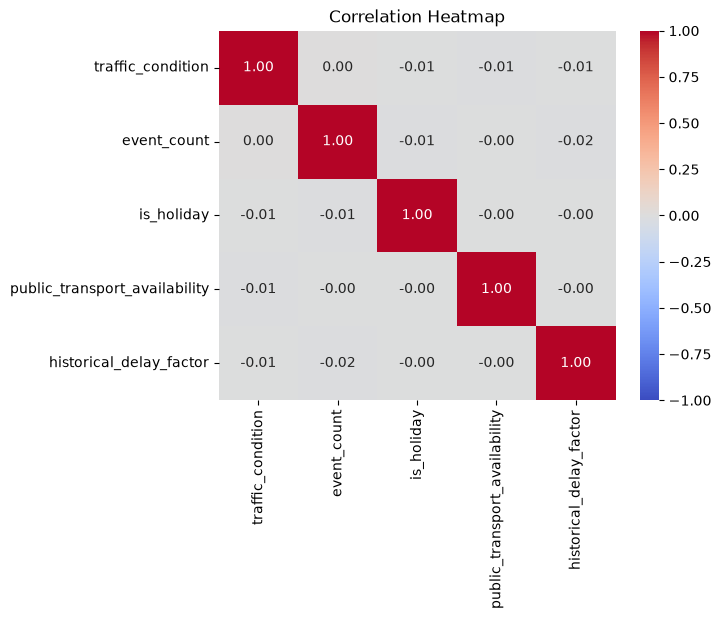

In [11]:
correlation = train_sample[numerical_columns].corr()
sns.heatmap(correlation,
           annot=True,
           cmap='coolwarm',
           fmt='.2f',
           vmin=-1,
           vmax=1)
plt.title('Correlation Heatmap')
plt.show()

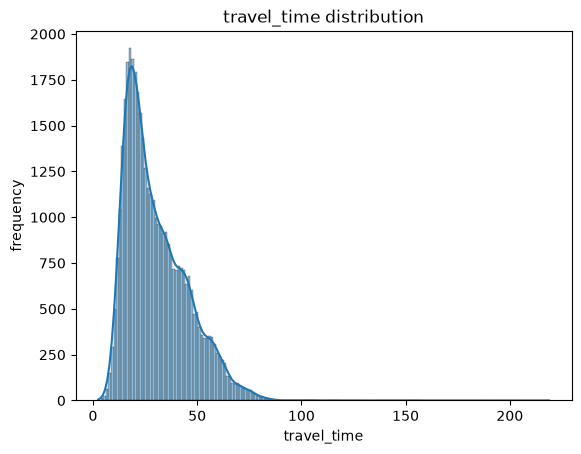

In [12]:
sns.histplot(train_sample["travel_time"], kde=True)
plt.title("travel_time distribution")
plt.xlabel("travel_time")
plt.ylabel("frequency")
plt.show()

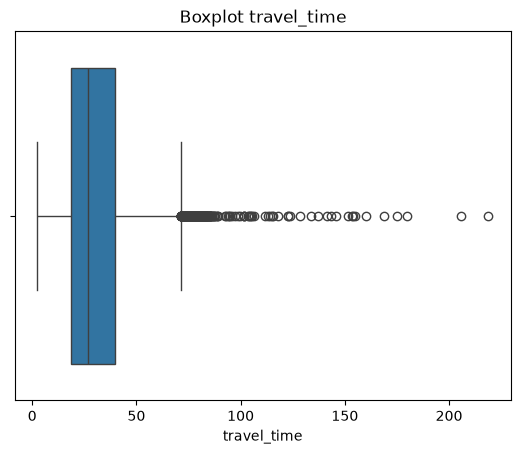

In [13]:
sns.boxplot(x=train_sample["travel_time"])
plt.title("Boxplot travel_time")
plt.xlabel("travel_time")
plt.show()

In [16]:
travel_time_outlier = train_sample[train_sample['travel_time'] > 150]
travel_time_outlier

,start_point,end_point,time_of_day,day_of_week,traffic_condition,event_count,is_holiday,vehicle_density,population_density,weather,public_transport_availability,historical_delay_factor,travel_time
4621,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Tuesday,9.0,7,1,NaN,NaN,rain,2,1.134454,151.533099
12796,West Jakarta (Jakarta Barat),East Jakarta (Jakarta Timur),evening,Friday,NaN,9,1,low,medium,fog,2,1.172938,154.854552
15135,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),morning,Saturday,9.0,9,1,NaN,low,NaN,2,0.799521,153.297186
16343,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Friday,NaN,9,0,low,low,NaN,2,0.936206,205.679832
18513,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Sunday,10.0,7,1,medium,medium,storm,2,1.652593,218.832465
21716,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Monday,9.0,8,0,low,NaN,storm,2,1.146816,168.697931
23387,North Jakarta (Jakarta Utara),South Jakarta (Jakarta Selatan),evening,Sunday,NaN,9,0,medium,low,rain,1,0.873401,153.943082
24718,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Tuesday,NaN,9,0,low,low,fog,2,1.232882,160.187804
26363,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),evening,Monday,NaN,8,0,low,low,fog,2,0.779995,174.899877
28747,North Jakarta (Jakarta Utara),East Jakarta (Jakarta Timur),day,Friday,3.0,7,0,medium,low,storm,2,0.900470,179.937114


# **Categorical & Discrete**

In [20]:
start = train_sample["start_point"].str.split().str[0]
end = train_sample["end_point"].str.split().str[0]

train_sample["start_end_point"] = start + " " + end

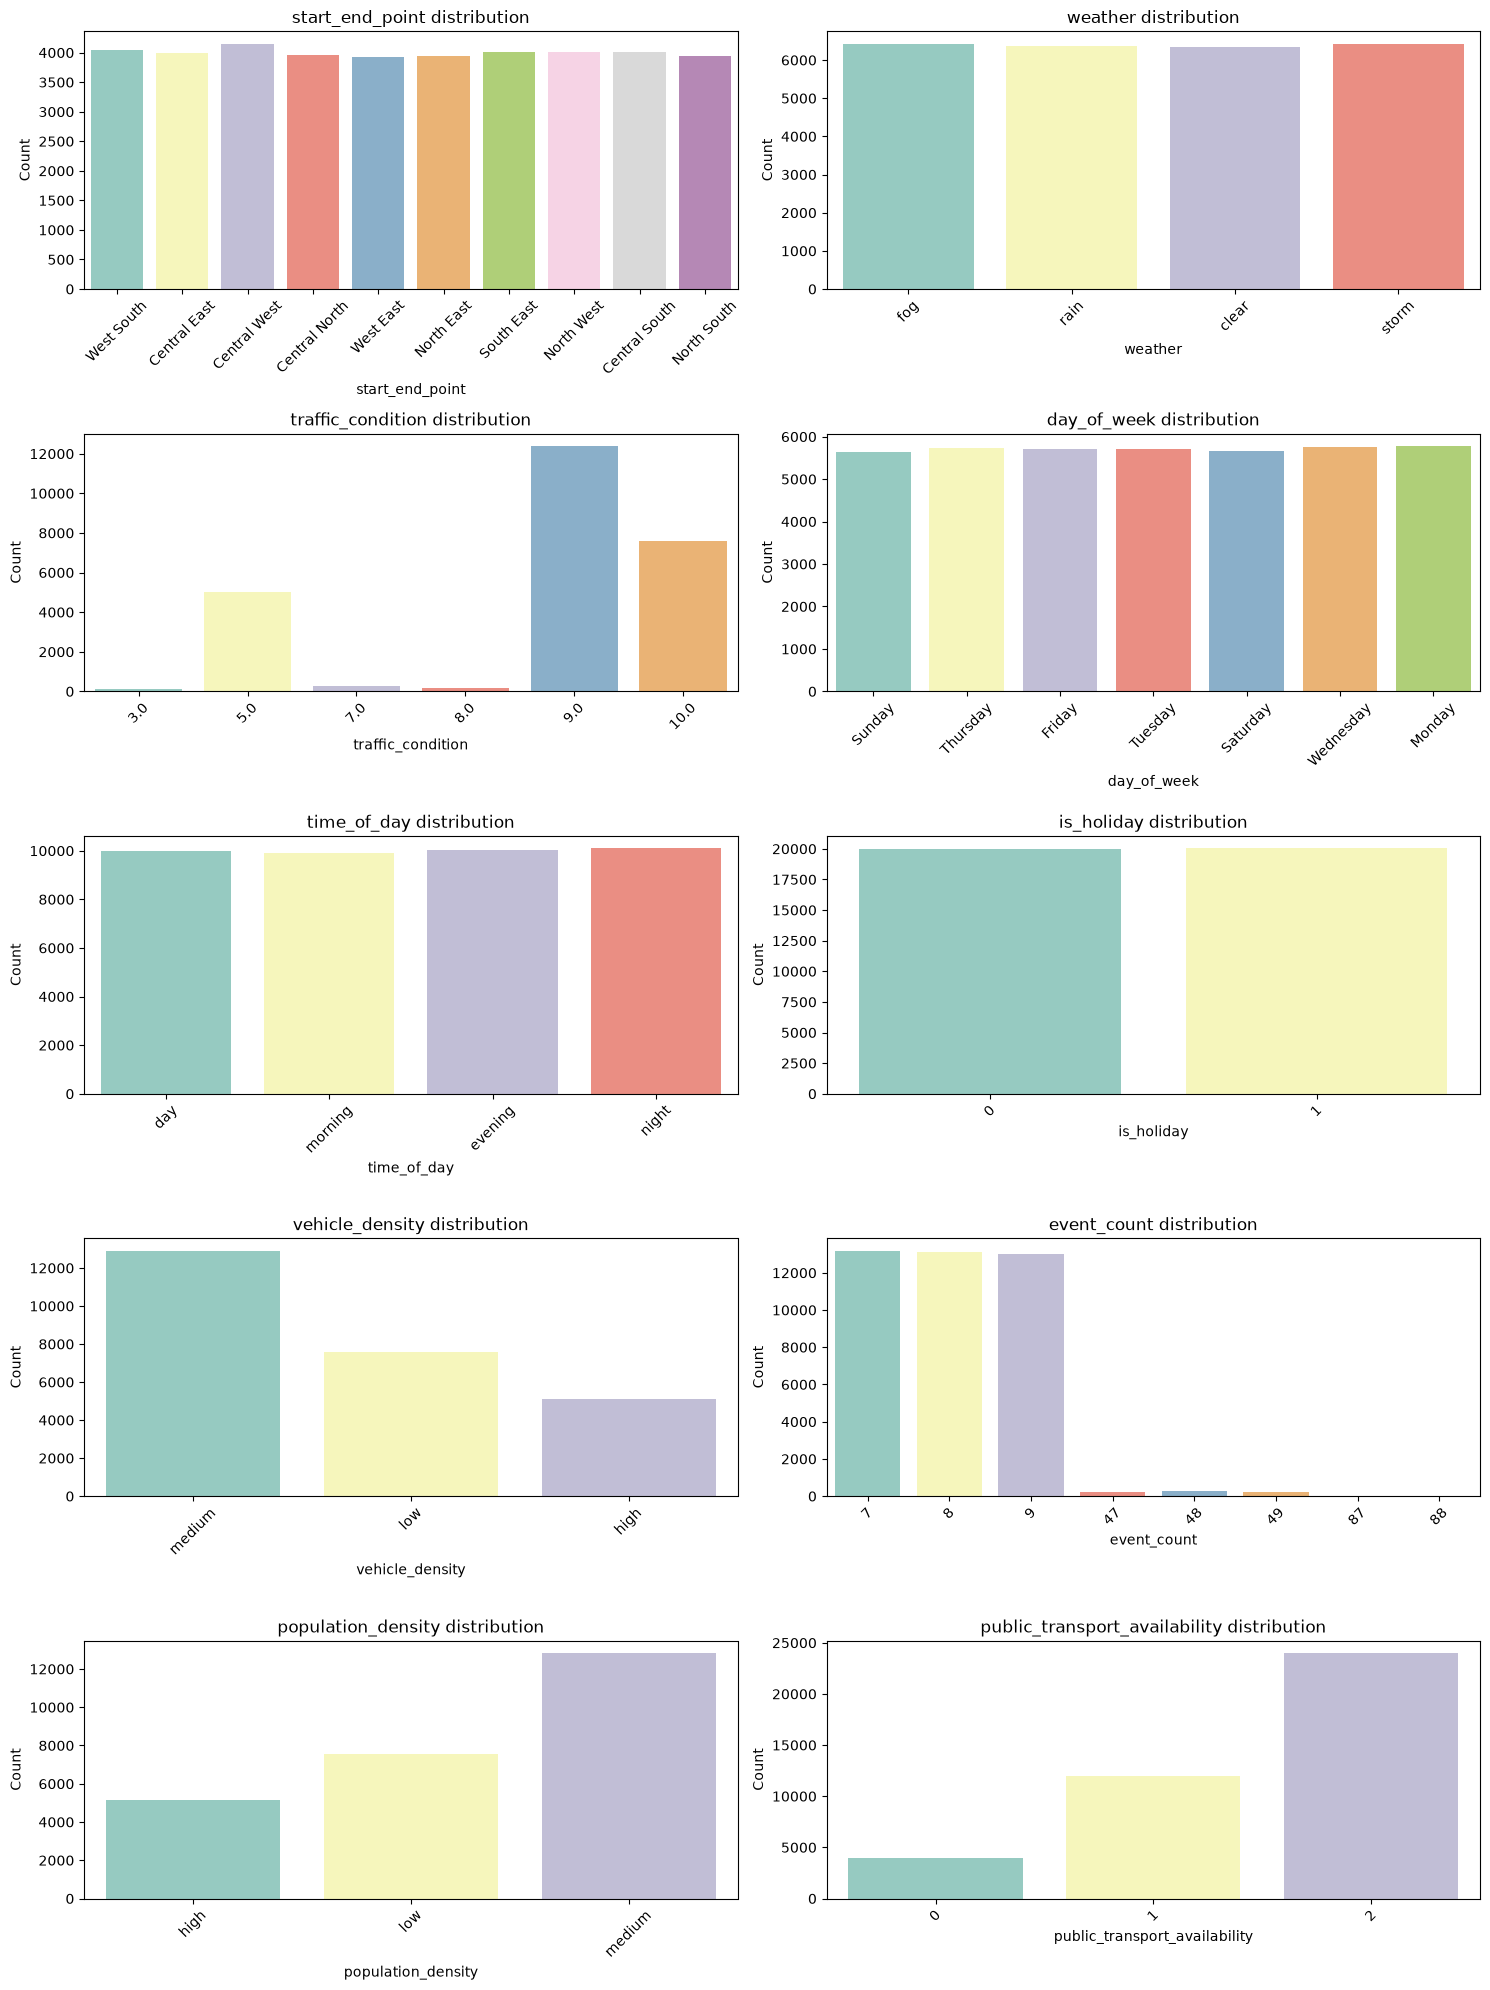

In [36]:
cat_discrete_cols = ['start_end_point', 'weather', 'traffic_condition', 'day_of_week', 'time_of_day', 'is_holiday', 'vehicle_density', 'event_count', 'population_density', 'public_transport_availability']

n_cols = 2
n_rows = (len(cat_discrete_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cat_discrete_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.countplot(data=train_sample, x=col, hue=col, palette="Set3", legend=False)
    
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

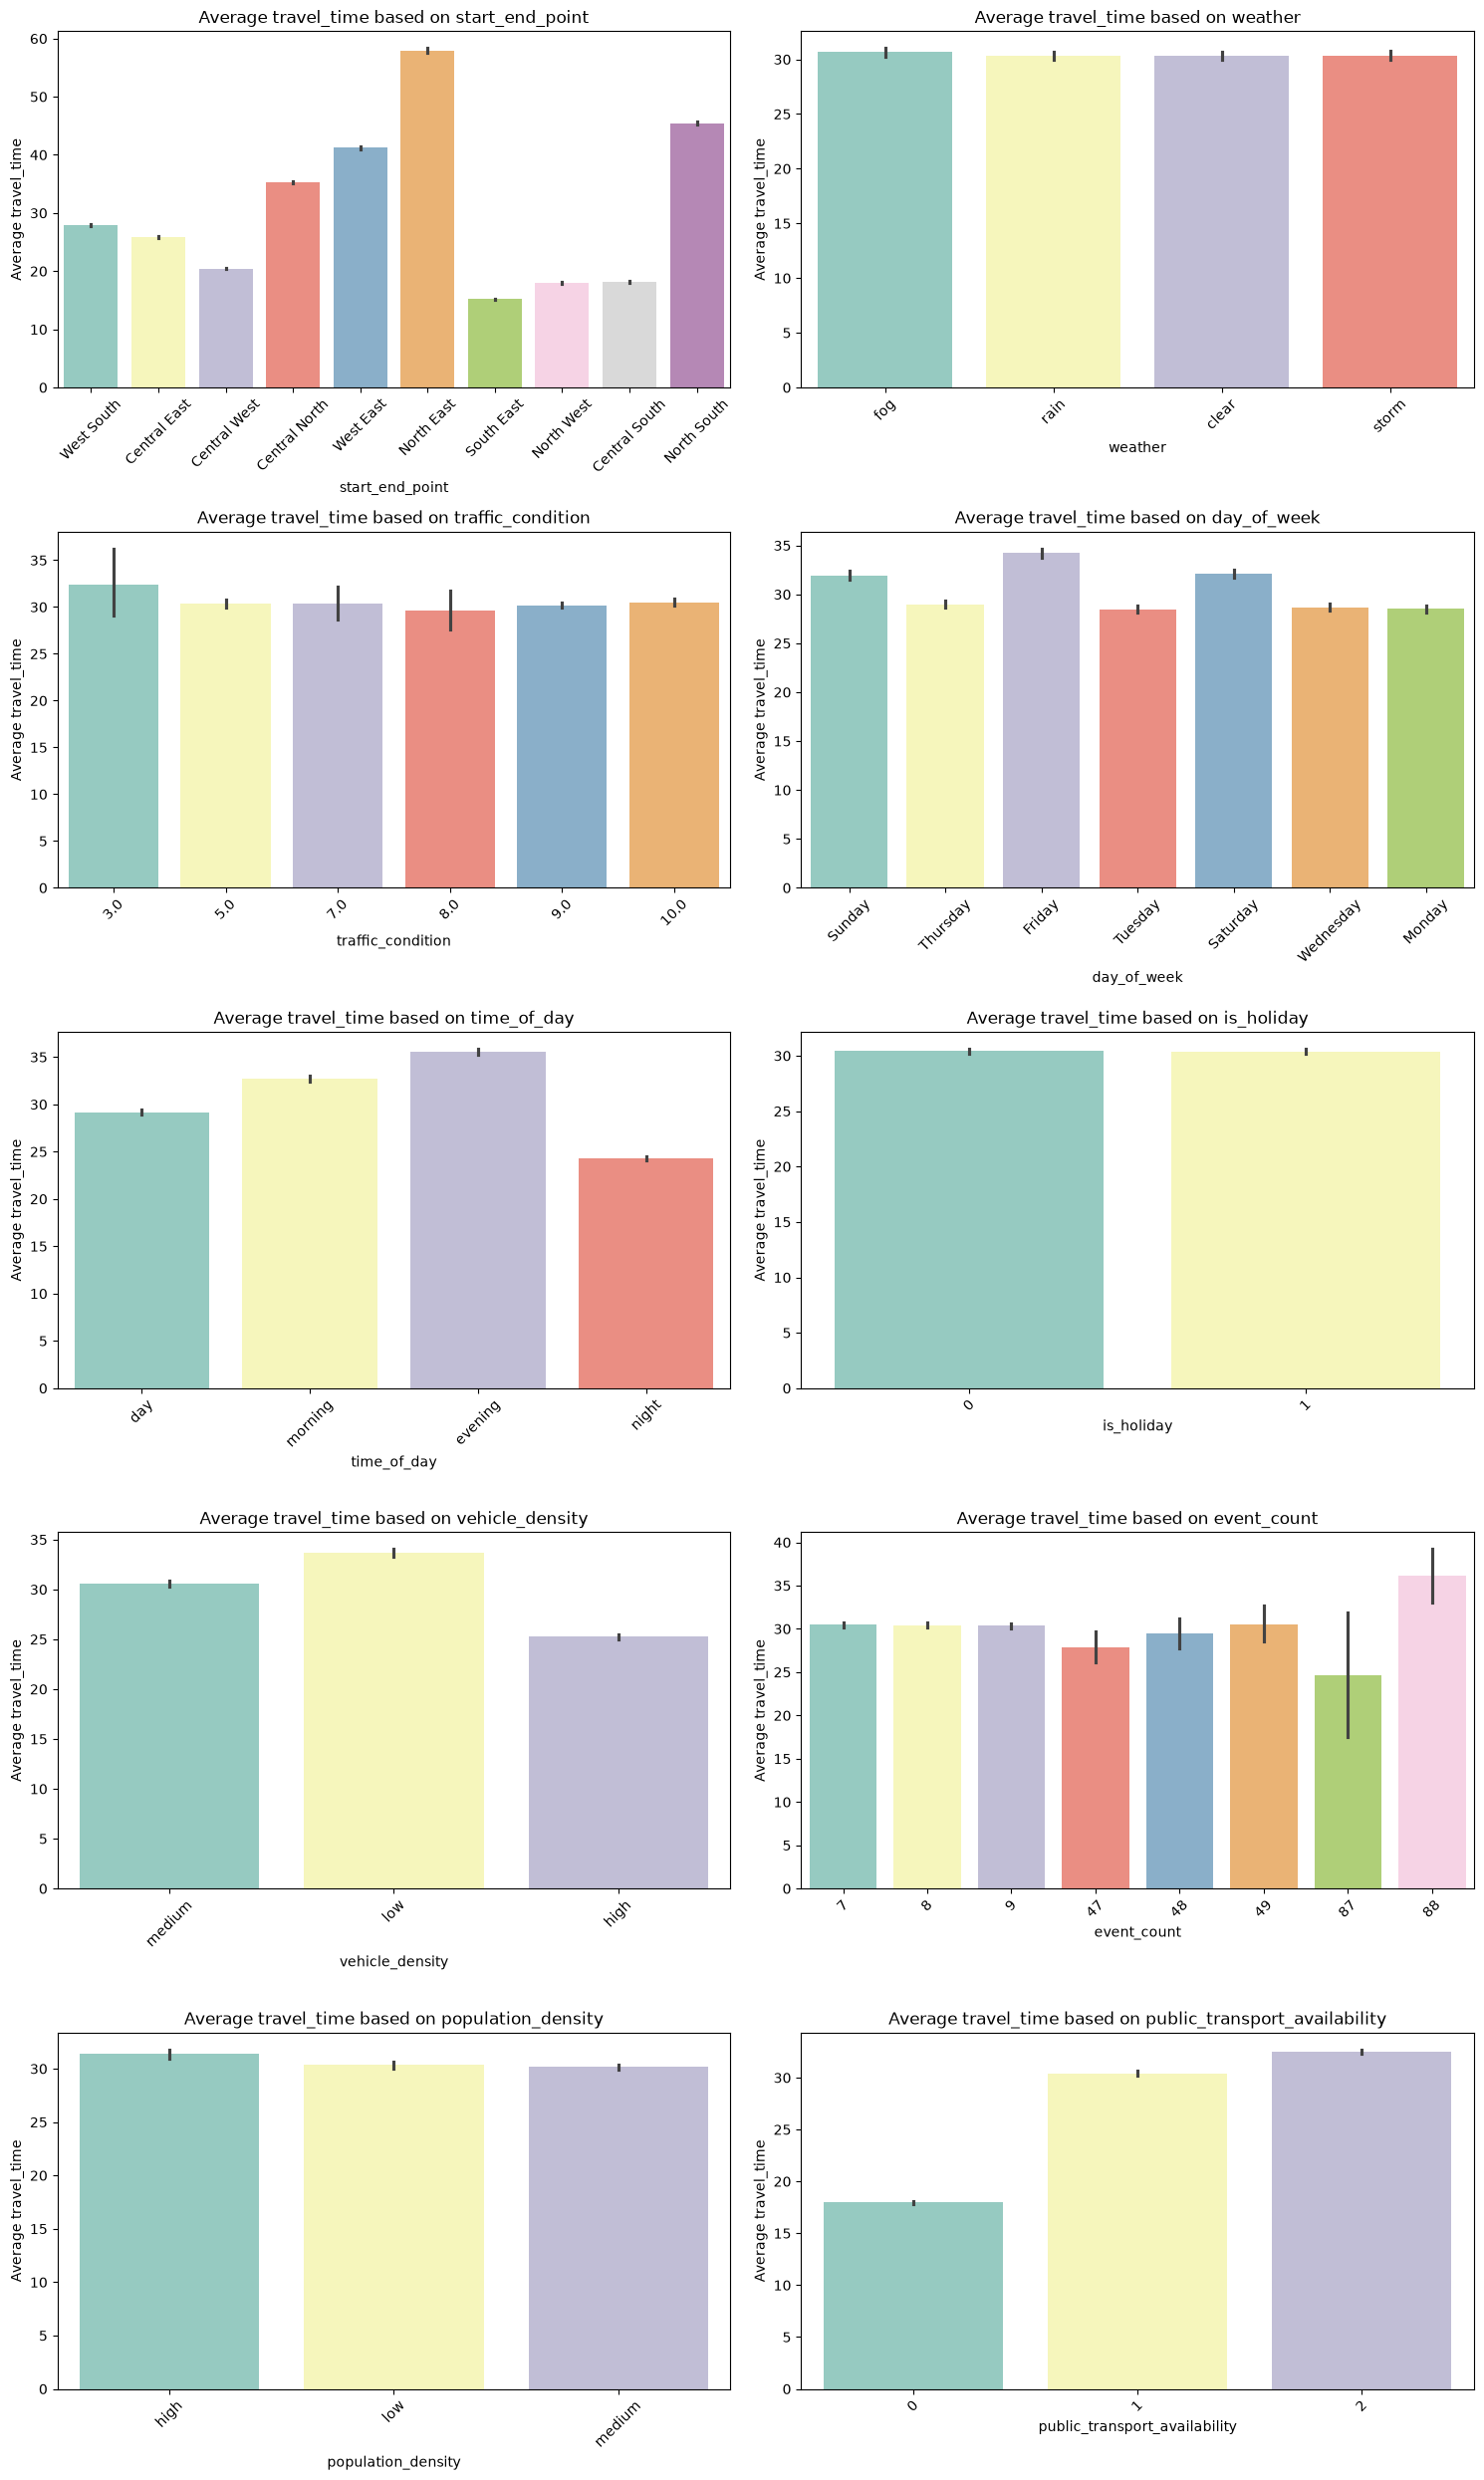

In [34]:
n_cols = 2
n_rows = (len(cat_discrete_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows)
)

# Biar axes tetap iterable kalau cuma ada 1 row
axes = axes.flatten()

for i, col in enumerate(cat_discrete_cols):

    sns.barplot(
        data=train_sample,
        x=col,
        y="travel_time",
        hue=col,
        ax=axes[i],
        palette="Set3",
        legend=False
    )

    axes[i].set_title(f"Average travel_time based on {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Average travel_time")
    axes[i].tick_params(axis="x", rotation=45)

# Hapus subplot kosong kalau jumlah kolom ganjil
for i in range(len(cat_discrete_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

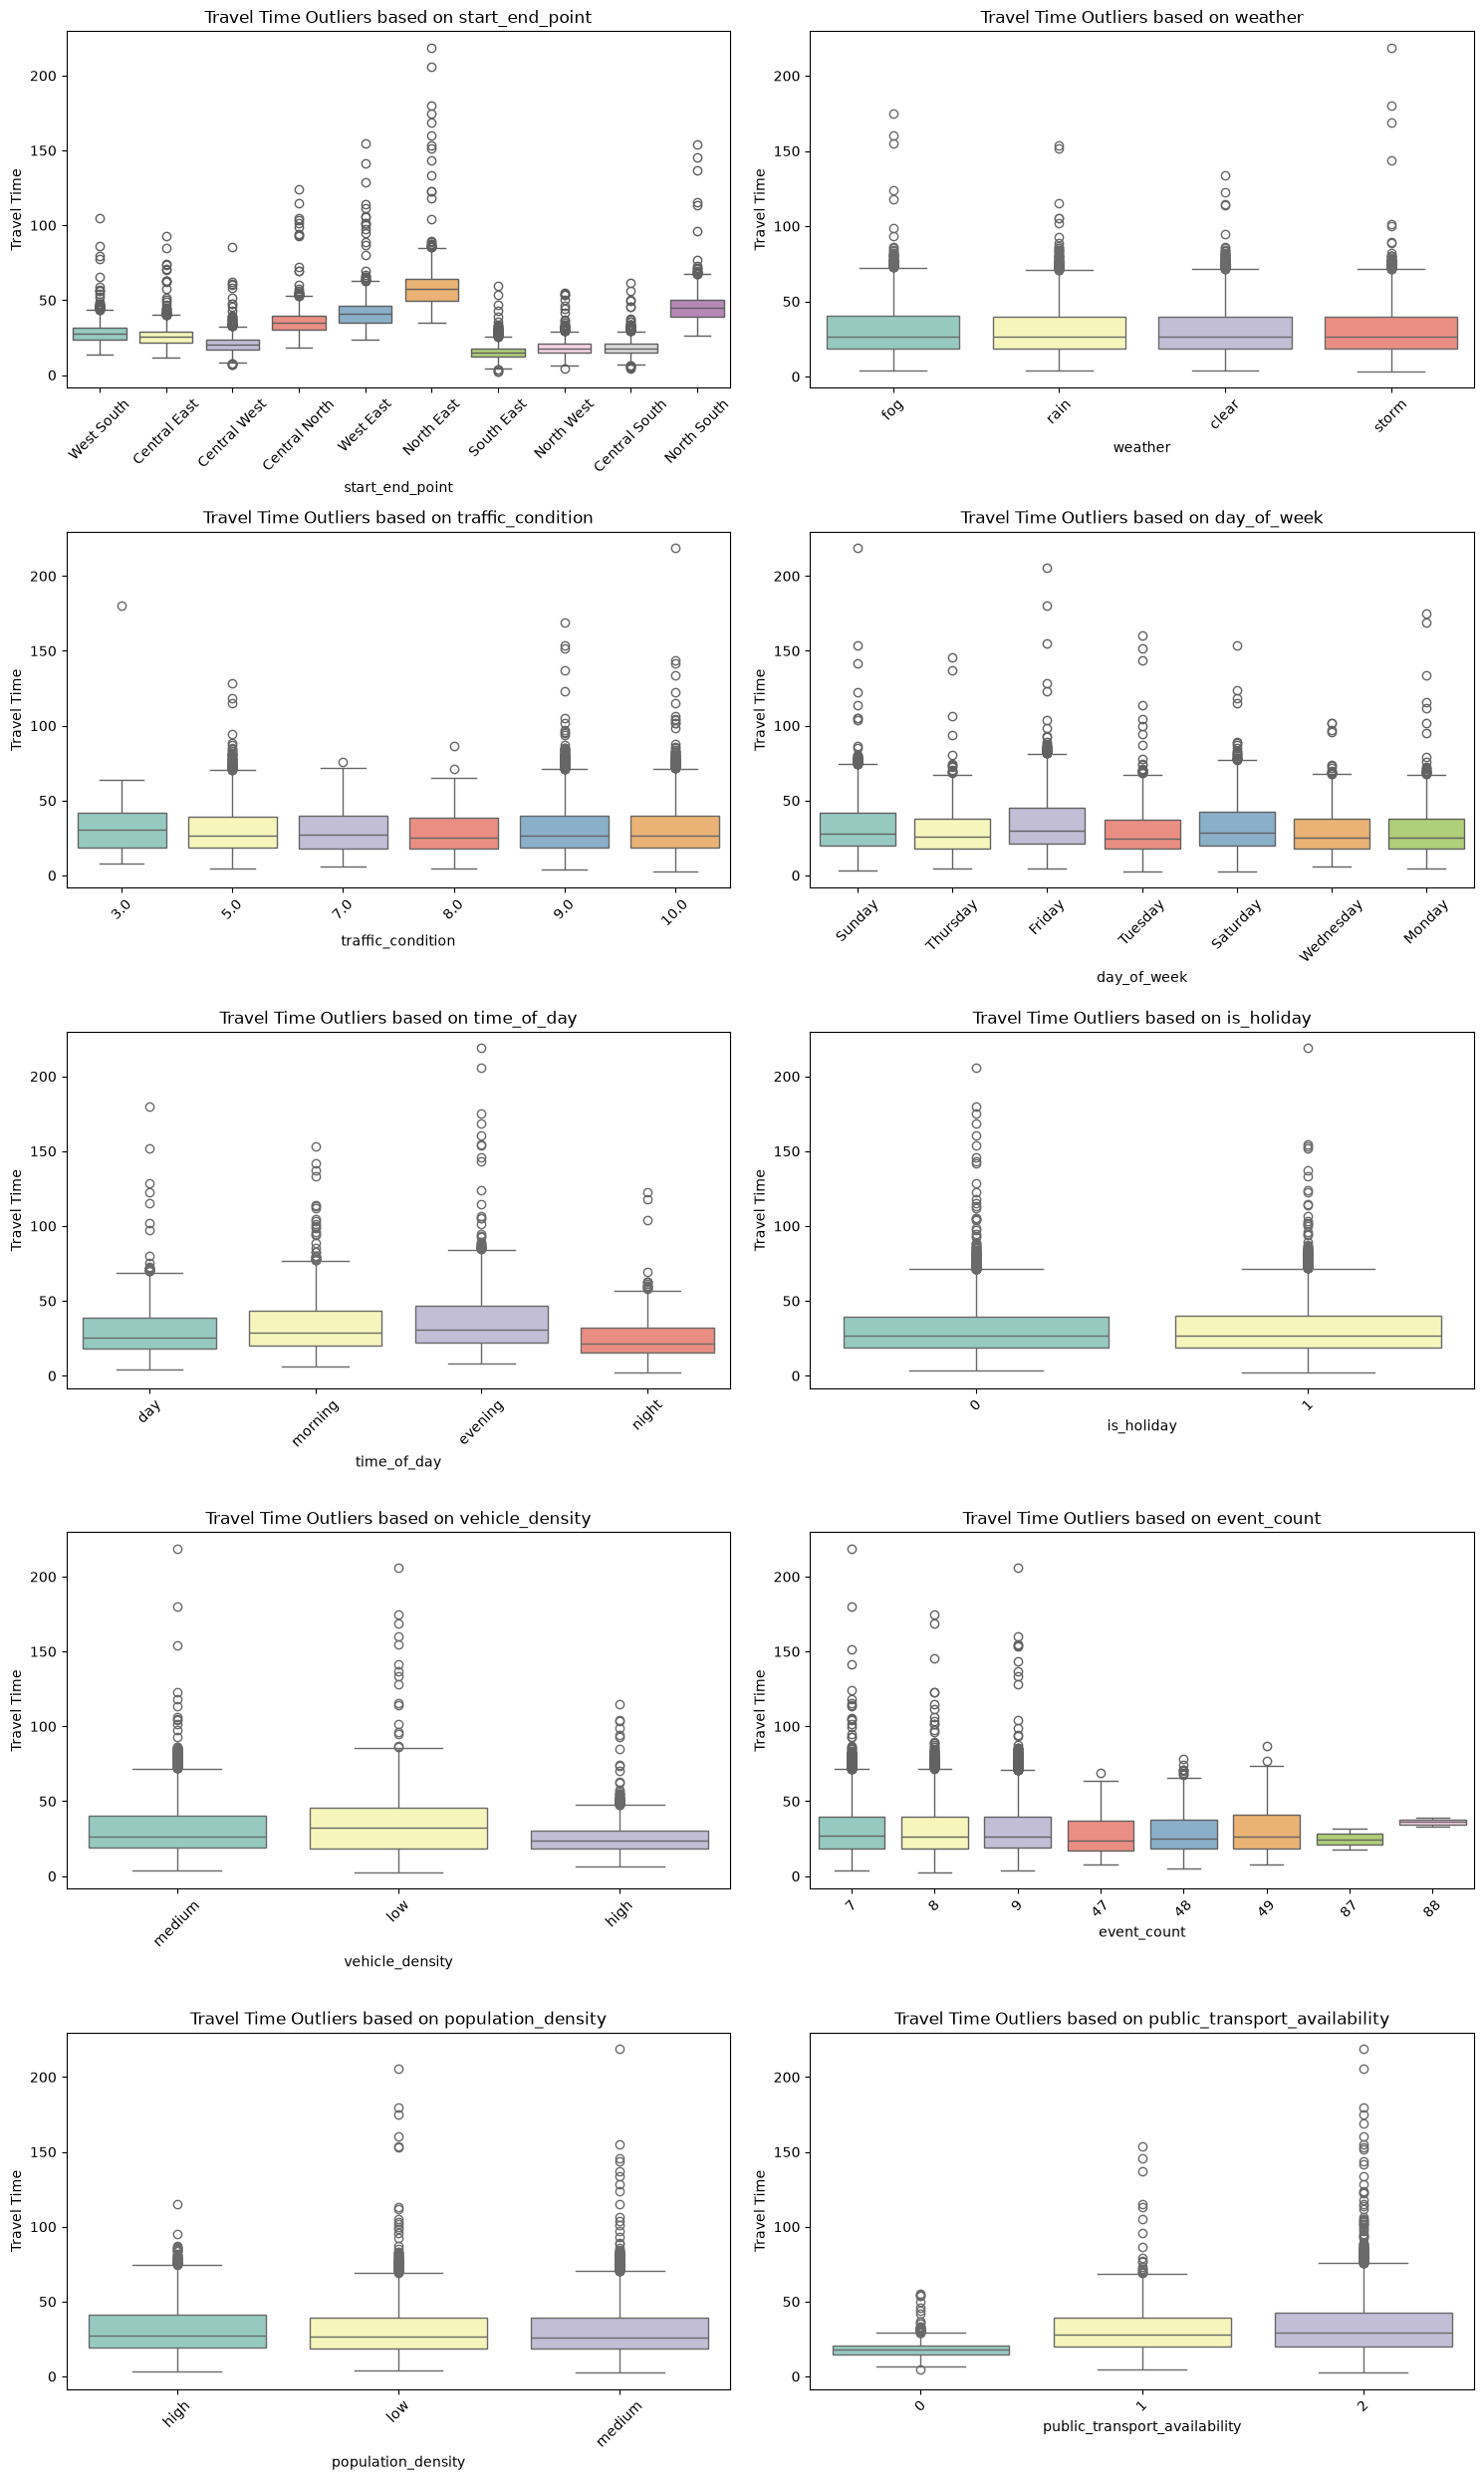

In [37]:
n_cols = 2
n_rows = (len(cat_discrete_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_discrete_cols):

    sns.boxplot(
        data=train_sample,
        x=col,
        y="travel_time",
        hue=col,
        ax=axes[i],
        palette="Set3",
        legend=False
    )

    axes[i].set_title(f"Travel Time Outliers based on {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Travel Time")
    axes[i].tick_params(axis="x", rotation=45)

# Hapus subplot kosong
for i in range(len(cat_discrete_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [38]:
Q1 = train_sample["travel_time"].quantile(0.25)
Q3 = train_sample["travel_time"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_df = train_sample[
    (train_sample["travel_time"] < lower_bound) |
    (train_sample["travel_time"] > upper_bound)
].copy()

print("Jumlah outlier:", len(outlier_df))

Jumlah outlier: 465


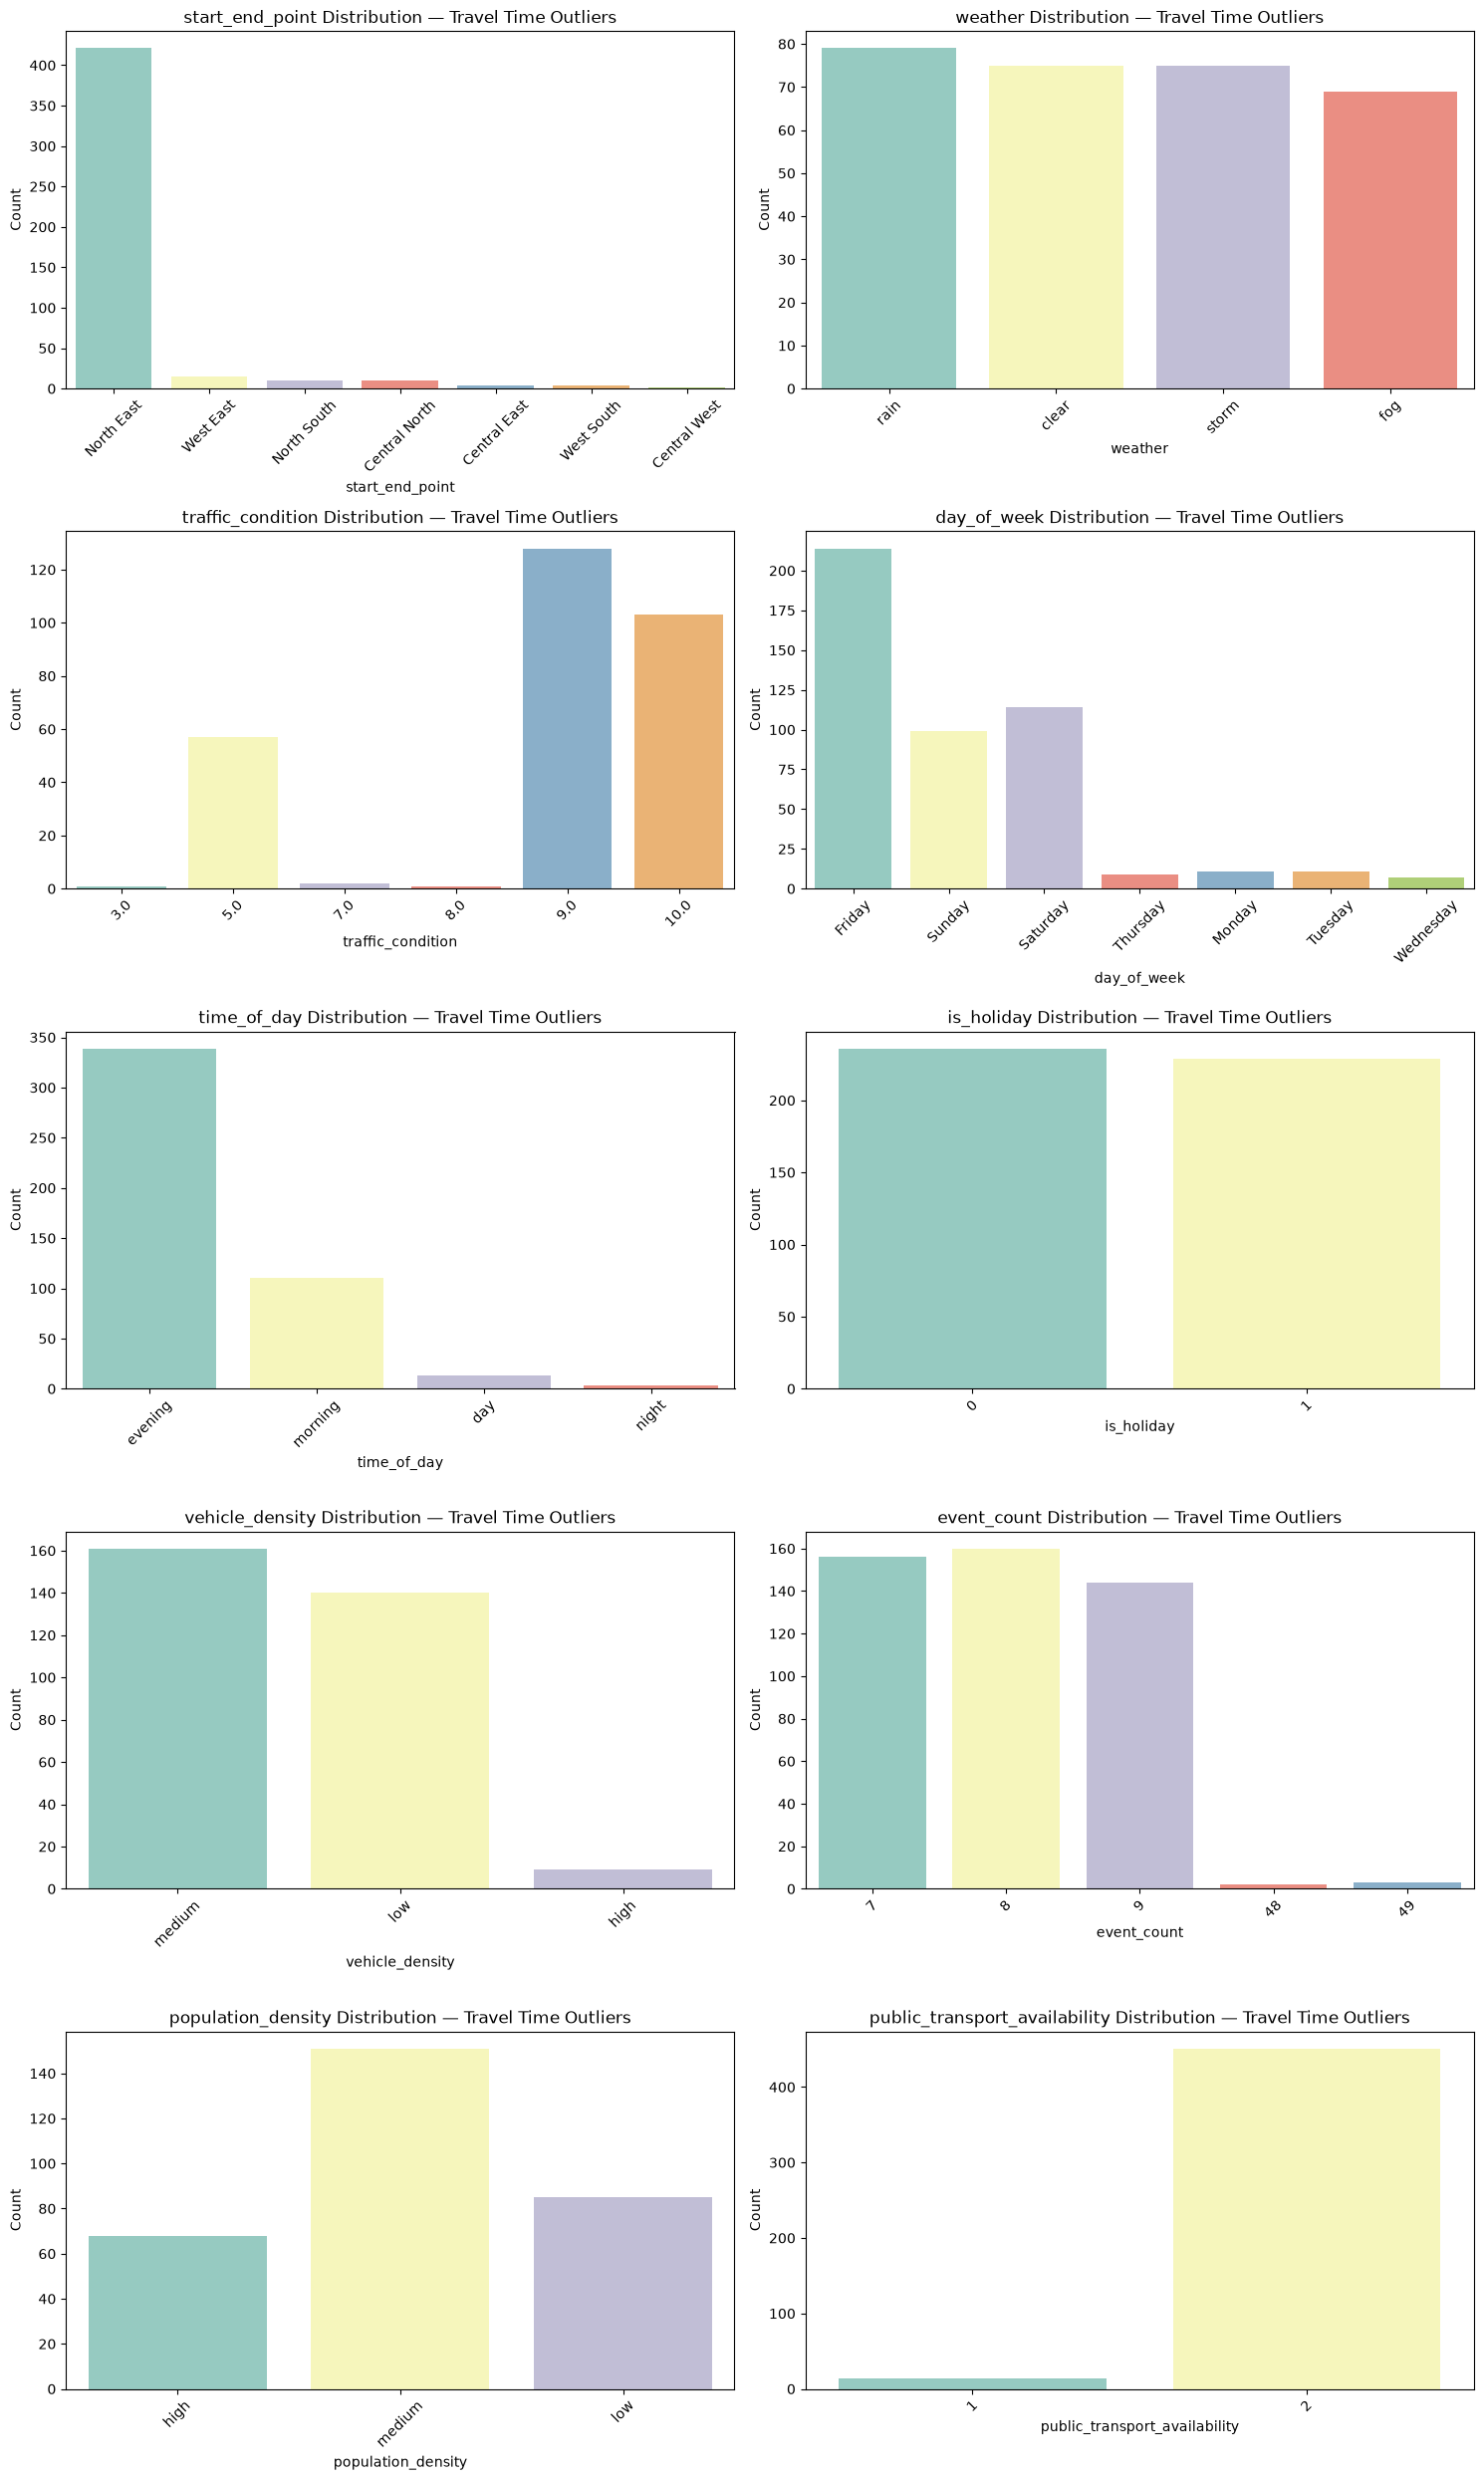

In [39]:
n_cols = 2
n_rows = (len(cat_discrete_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_discrete_cols):

    sns.countplot(
        data=outlier_df,
        x=col,
        hue=col,
        ax=axes[i],
        palette="Set3",
        legend=False
    )

    axes[i].set_title(f"{col} Distribution — Travel Time Outliers")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Hapus subplot kosong
for i in range(len(cat_discrete_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# ****